# Marketing Funnel & Conversion Performance Analysis

### Future Interns — Data Science & Analytics Internship

**Task:** Task 3 — Marketing Funnel & Conversion Performance Analysis  
**Track:** Data Science & Analytics  
**Tool:** Python / Google Colab  
**Dataset:** Bank Marketing Campaign Dataset

## Project Overview

This project analyzes a bank marketing campaign to understand customer responses and identify factors associated with successful conversions.

The analysis focuses on customer characteristics, campaign-related factors, contact methods, and previous campaign outcomes to identify patterns that can help improve marketing conversion performance.

## Business Questions

- What is the overall conversion rate of the marketing campaign?
- Which customer segments are more likely to convert?
- How do different contact methods affect conversion?
- Which campaign factors are associated with successful conversions?
- How does previous campaign outcome influence current conversion?
- Where do the major non-conversion patterns occur?
- What strategies can improve future marketing campaign performance?

## 1. Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Loading the Dataset

In [2]:
df = pd.read_csv('/content/bank-full.csv', sep=';')

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (45211, 17)


## 3. Understanding the Dataset

In [3]:
# Display the first five rows of the dataset
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
# Display information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [5]:
# Check for missing values in each column
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [6]:
# Check for duplicate records
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [7]:
# Check the distribution of the campaign outcome
print("Campaign outcome counts:")
print(df['y'].value_counts())

print("\nCampaign outcome percentages:")
print(df['y'].value_counts(normalize=True) * 100)

Campaign outcome counts:
y
no     39922
yes     5289
Name: count, dtype: int64

Campaign outcome percentages:
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


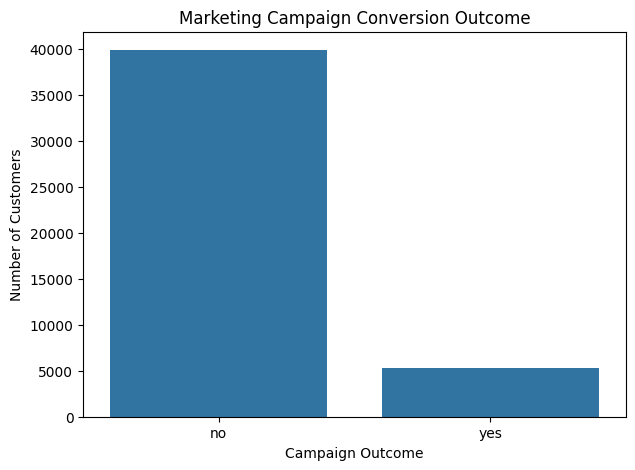

In [8]:
# Visualize campaign conversion outcome

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='y')

plt.title('Marketing Campaign Conversion Outcome')
plt.xlabel('Campaign Outcome')
plt.ylabel('Number of Customers')

plt.show()

In [9]:
# Calculate the overall conversion rate

conversion_rate = (df['y'] == 'yes').mean() * 100

print(f"Overall Conversion Rate: {conversion_rate:.2f}%")

Overall Conversion Rate: 11.70%


In [10]:
# Calculate conversion rate by job category

job_conversion = (
    df.groupby('job')['y']
      .apply(lambda x: (x == 'yes').mean() * 100)
      .sort_values(ascending=False)
)

print("Conversion rate by job category:")
print(job_conversion.round(2))

Conversion rate by job category:
job
student          28.68
retired          22.79
unemployed       15.50
management       13.76
admin.           12.20
self-employed    11.84
unknown          11.81
technician       11.06
services          8.88
housemaid         8.79
entrepreneur      8.27
blue-collar       7.27
Name: y, dtype: float64


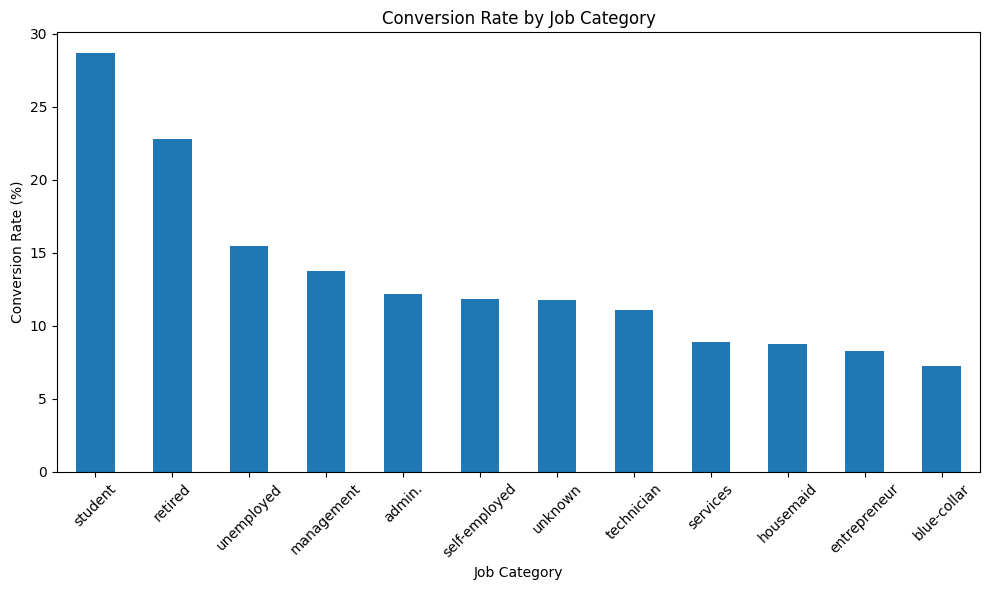

In [11]:
# Visualize conversion rate by job category

plt.figure(figsize=(10, 6))

job_conversion.plot(kind='bar')

plt.title('Conversion Rate by Job Category')
plt.xlabel('Job Category')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [12]:
# Calculate conversion rate by contact method

contact_conversion = (
    df.groupby('contact')['y']
      .apply(lambda x: (x == 'yes').mean() * 100)
      .sort_values(ascending=False)
)

print("Conversion rate by contact method:")
print(contact_conversion.round(2))

Conversion rate by contact method:
contact
cellular     14.92
telephone    13.42
unknown       4.07
Name: y, dtype: float64


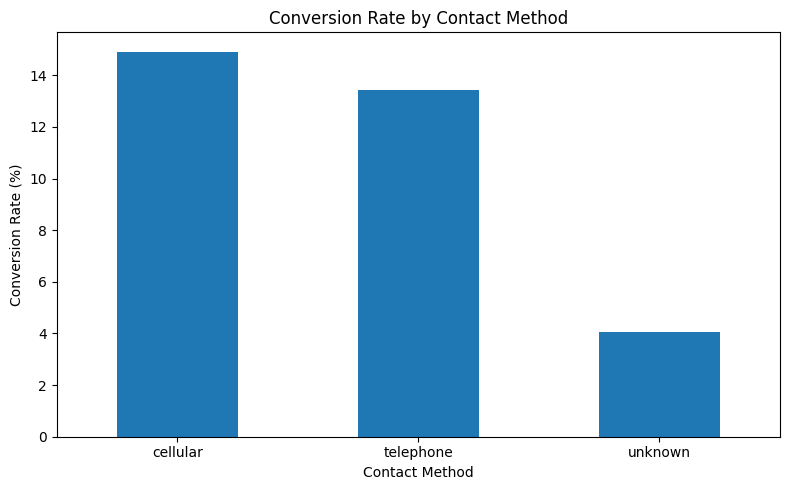

In [13]:
# Visualize conversion rate by contact method

plt.figure(figsize=(8, 5))

contact_conversion.plot(kind='bar')

plt.title('Conversion Rate by Contact Method')
plt.xlabel('Contact Method')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [14]:
# Calculate conversion rate by previous campaign outcome

previous_conversion = (
    df.groupby('poutcome')['y']
      .apply(lambda x: (x == 'yes').mean() * 100)
      .sort_values(ascending=False)
)

print("Conversion rate by previous campaign outcome:")
print(previous_conversion.round(2))

Conversion rate by previous campaign outcome:
poutcome
success    64.73
other      16.68
failure    12.61
unknown     9.16
Name: y, dtype: float64


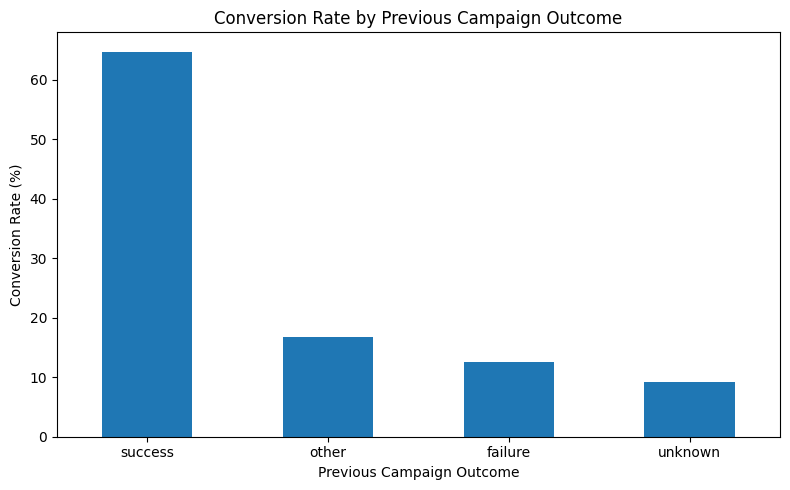

In [15]:
# Visualize conversion rate by previous campaign outcome

plt.figure(figsize=(8, 5))

previous_conversion.plot(kind='bar')

plt.title('Conversion Rate by Previous Campaign Outcome')
plt.xlabel('Previous Campaign Outcome')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [16]:
# Calculate conversion rate by number of contacts

campaign_conversion = (
    df.groupby('campaign')['y']
      .apply(lambda x: (x == 'yes').mean() * 100)
)

print("Conversion rate by number of contacts:")
print(campaign_conversion.round(2))

Conversion rate by number of contacts:
campaign
1     14.60
2     11.20
3     11.19
4      9.00
5      7.88
6      7.13
7      6.39
8      5.93
9      6.42
10     5.26
11     7.96
12     2.58
13     4.51
14     4.30
15     4.76
16     2.53
17     8.70
18     0.00
19     0.00
20     2.33
21     2.86
22     0.00
23     0.00
24     5.00
25     0.00
26     0.00
27     0.00
28     0.00
29     6.25
30     0.00
31     0.00
32    11.11
33     0.00
34     0.00
35     0.00
36     0.00
37     0.00
38     0.00
39     0.00
41     0.00
43     0.00
44     0.00
46     0.00
50     0.00
51     0.00
55     0.00
58     0.00
63     0.00
Name: y, dtype: float64


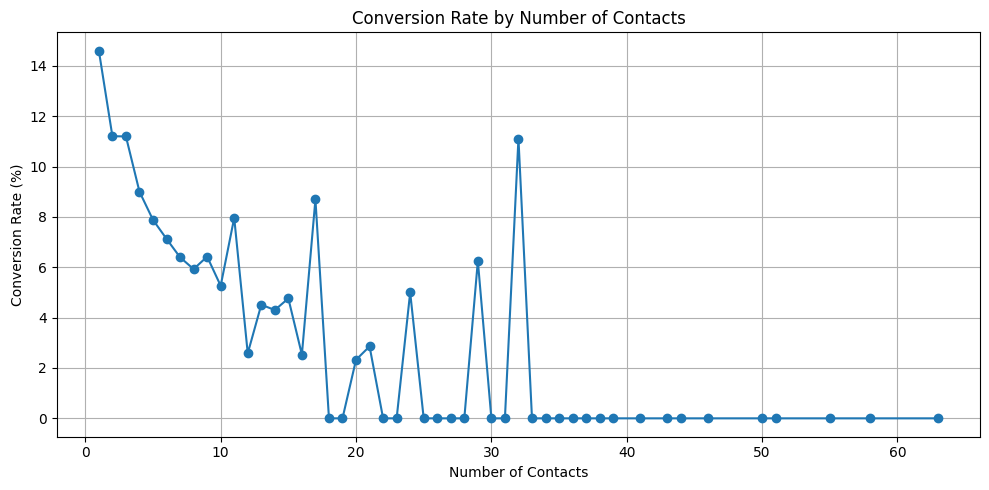

In [17]:
# Visualize conversion rate by number of contacts

plt.figure(figsize=(10, 5))

plt.plot(campaign_conversion.index, campaign_conversion.values, marker='o')

plt.title('Conversion Rate by Number of Contacts')
plt.xlabel('Number of Contacts')
plt.ylabel('Conversion Rate (%)')
plt.grid(True)
plt.tight_layout()

plt.show()

In [18]:
# Create age groups

bins = [0, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '66+']

df['age_group'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print("Age groups created successfully.")
print(df['age_group'].value_counts().sort_index())

Age groups created successfully.
age_group
18-25     1336
26-35    15571
36-45    13856
46-55     9548
56-65     4149
66+        751
Name: count, dtype: int64


In [19]:
# Calculate conversion rate by age group

age_conversion = (
    df.groupby('age_group', observed=True)['y']
      .apply(lambda x: (x == 'yes').mean() * 100)
)

print("Conversion rate by age group:")
print(age_conversion.round(2))

Conversion rate by age group:
age_group
18-25    23.95
26-35    12.00
36-45     9.39
46-55     9.35
56-65    14.12
66+      42.61
Name: y, dtype: float64


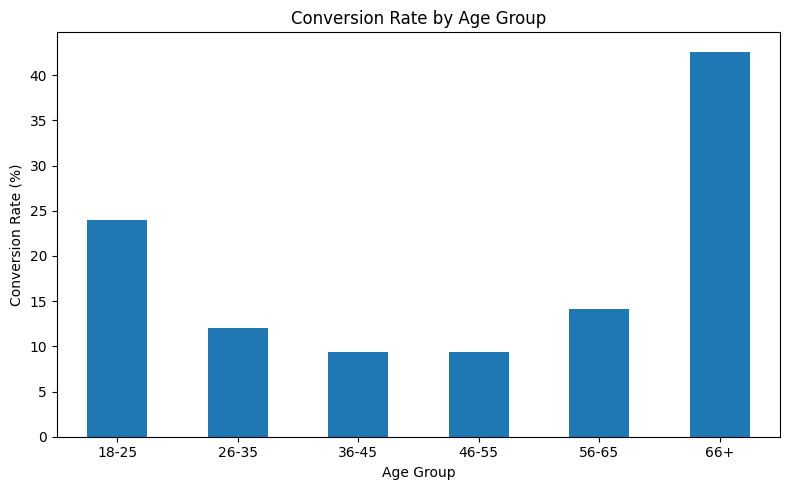

In [20]:
# Visualize conversion rate by age group

plt.figure(figsize=(8, 5))

age_conversion.plot(kind='bar')

plt.title('Conversion Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [21]:
# Compare average call duration for converted and non-converted customers

duration_summary = df.groupby('y')['duration'].mean()

print("Average call duration by campaign outcome:")
print(duration_summary.round(2))

Average call duration by campaign outcome:
y
no     221.18
yes    537.29
Name: duration, dtype: float64


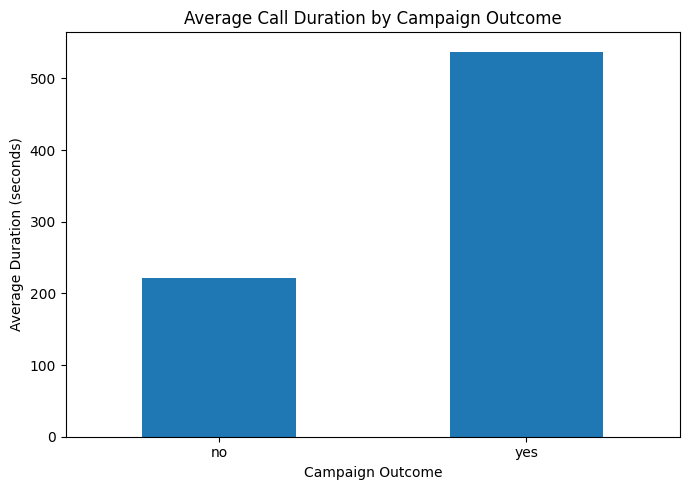

In [22]:
# Visualize average call duration by campaign outcome

plt.figure(figsize=(7, 5))

duration_summary.plot(kind='bar')

plt.title('Average Call Duration by Campaign Outcome')
plt.xlabel('Campaign Outcome')
plt.ylabel('Average Duration (seconds)')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

## 4. Key Findings

In [23]:
# Generate key conversion metrics

total_customers = len(df)
converted_customers = (df['y'] == 'yes').sum()
conversion_rate = (converted_customers / total_customers) * 100

top_job = job_conversion.index[0]
top_job_rate = job_conversion.iloc[0]

top_contact = contact_conversion.index[0]
top_contact_rate = contact_conversion.iloc[0]

top_previous = previous_conversion.index[0]
top_previous_rate = previous_conversion.iloc[0]

print(f"Total customers contacted: {total_customers:,}")
print(f"Customers converted: {converted_customers:,}")
print(f"Overall conversion rate: {conversion_rate:.2f}%")
print(f"Highest-converting job category: {top_job} ({top_job_rate:.2f}%)")
print(f"Highest-converting contact method: {top_contact} ({top_contact_rate:.2f}%)")
print(f"Highest-converting previous campaign outcome: {top_previous} ({top_previous_rate:.2f}%)")

Total customers contacted: 45,211
Customers converted: 5,289
Overall conversion rate: 11.70%
Highest-converting job category: student (28.68%)
Highest-converting contact method: cellular (14.92%)
Highest-converting previous campaign outcome: success (64.73%)


## 5. Marketing Campaign Dashboard

In [24]:
# Calculate key dashboard metrics

total_customers = len(df)
converted_customers = (df['y'] == 'yes').sum()
conversion_rate = (converted_customers / total_customers) * 100
non_converted_customers = (df['y'] == 'no').sum()

print("MARKETING CAMPAIGN DASHBOARD")
print("-" * 35)
print(f"Total Customers       : {total_customers:,}")
print(f"Converted Customers   : {converted_customers:,}")
print(f"Non-Converted         : {non_converted_customers:,}")
print(f"Conversion Rate       : {conversion_rate:.2f}%")

MARKETING CAMPAIGN DASHBOARD
-----------------------------------
Total Customers       : 45,211
Converted Customers   : 5,289
Non-Converted         : 39,922
Conversion Rate       : 11.70%


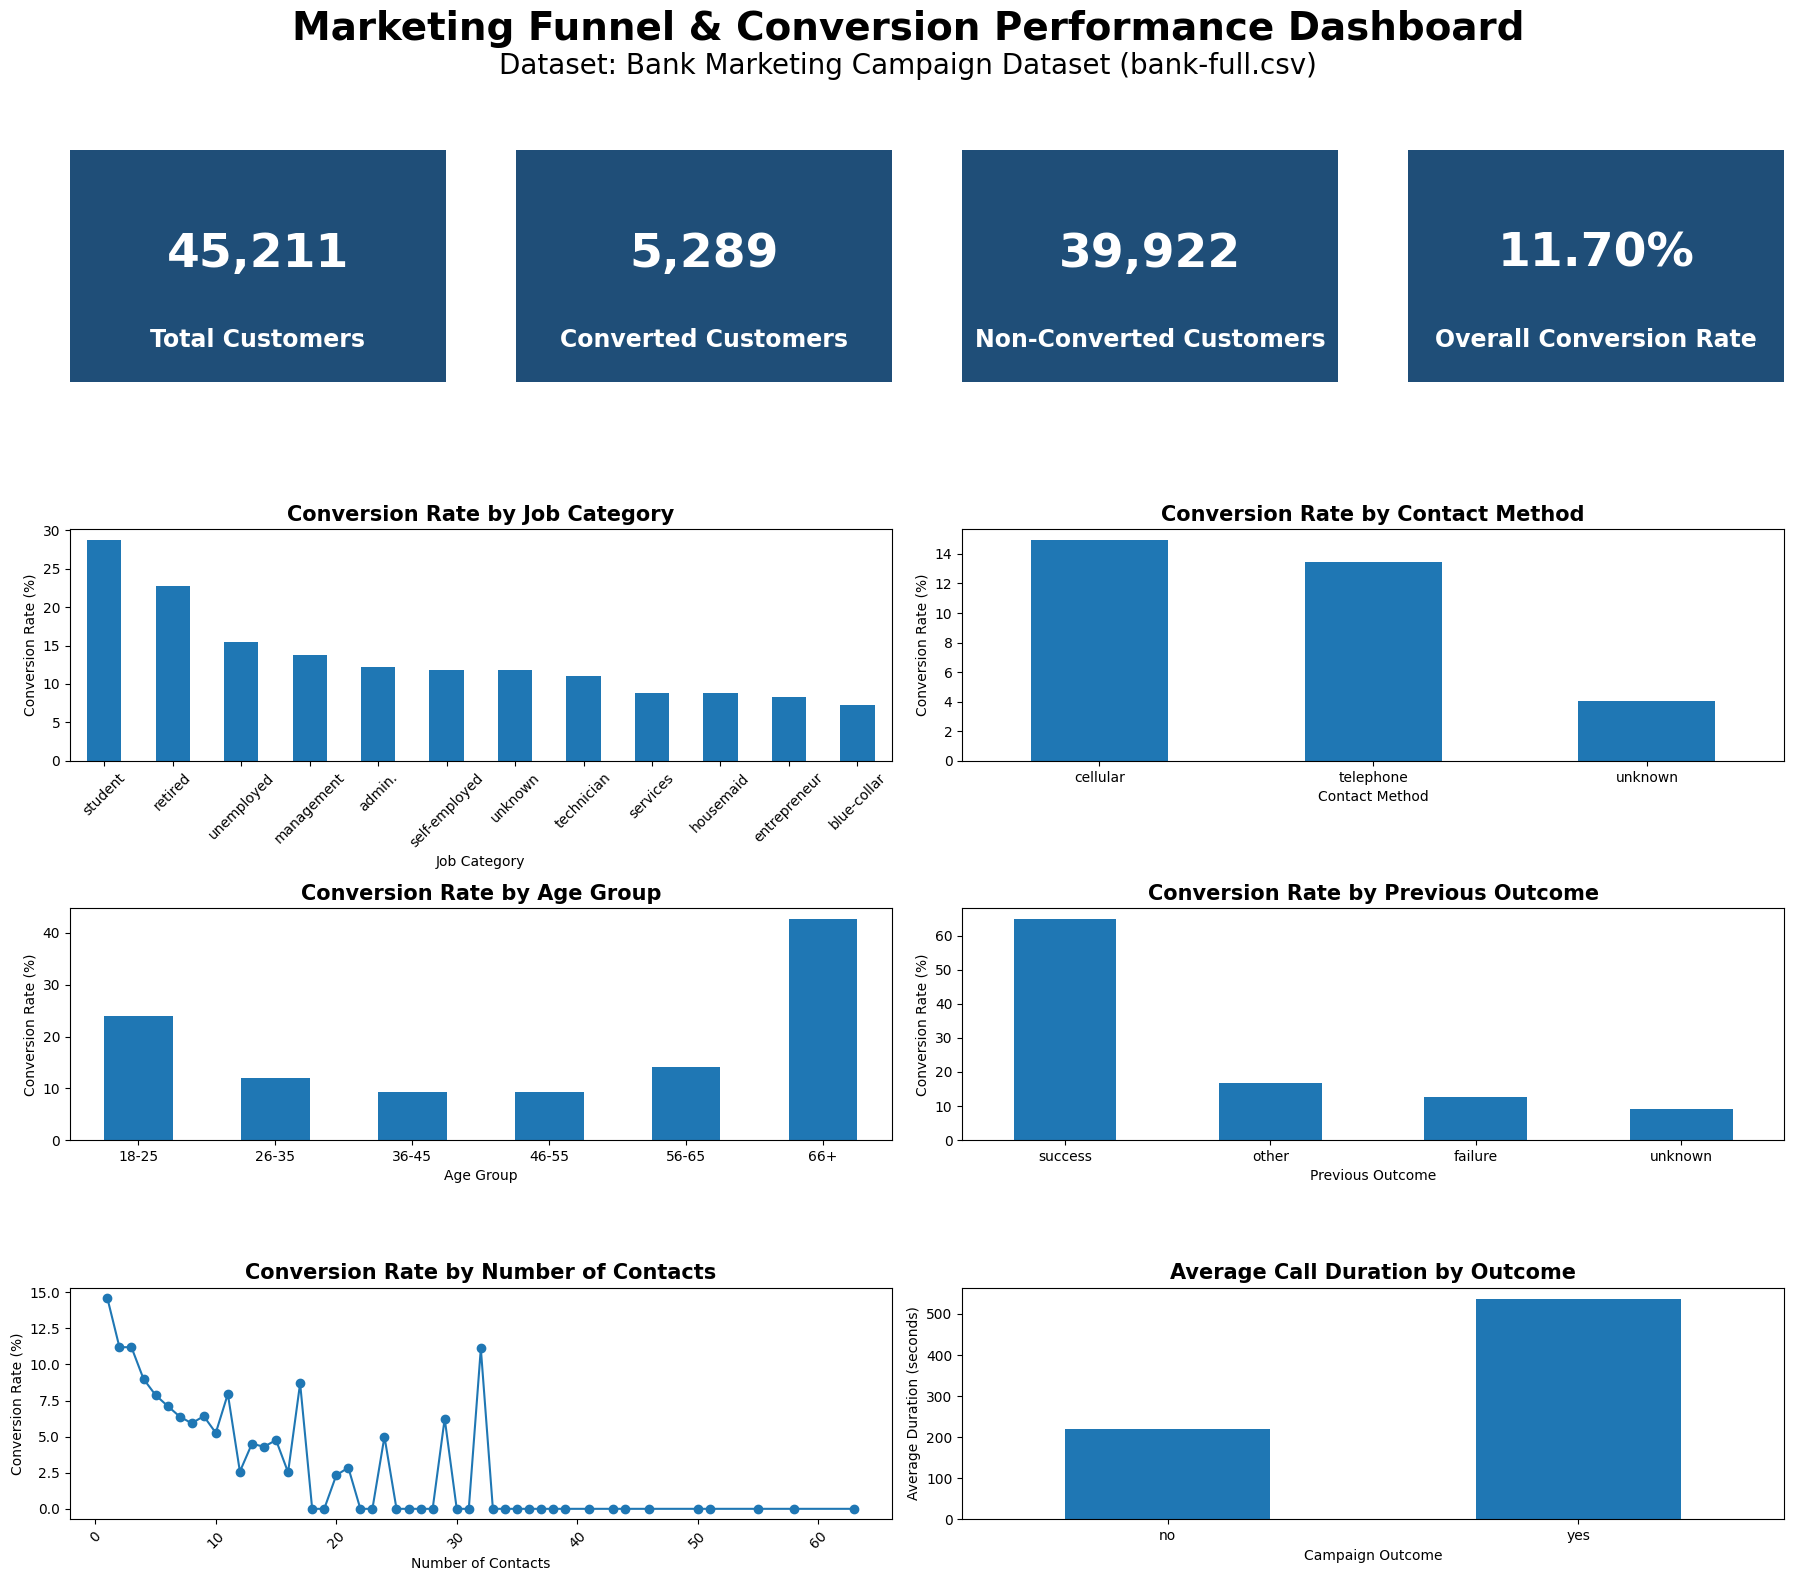

In [34]:
fig = plt.figure(figsize=(18, 16))

# ================= MAIN TITLE =================

fig.suptitle(
    'Marketing Funnel & Conversion Performance Dashboard',
    fontsize=28,
    fontweight='bold',
    y=0.985
)

# Dataset subtitle
fig.text(
    0.5, 0.945,
    'Dataset: Bank Marketing Campaign Dataset (bank-full.csv)',
    ha='center',
    fontsize=20
)


# ================= KPI CARD COLOR =================

kpi_color = '#1F4E78'   # Professional navy blue


# ================= KPI CARDS =================

# KPI 1: Total Customers
ax1 = plt.subplot2grid((4, 4), (0, 0))
ax1.set_facecolor(kpi_color)

ax1.text(
    0.5, 0.55,
    f'{total_customers:,}',
    ha='center',
    va='center',
    fontsize=34,
    fontweight='bold',
    color='white'
)

ax1.text(
    0.5, 0.18,
    'Total Customers',
    ha='center',
    va='center',
    fontsize=17,
    fontweight='bold',
    color='white'
)

ax1.set_xticks([])
ax1.set_yticks([])

for spine in ax1.spines.values():
    spine.set_visible(False)


# KPI 2: Converted Customers
ax2 = plt.subplot2grid((4, 4), (0, 1))
ax2.set_facecolor(kpi_color)

ax2.text(
    0.5, 0.55,
    f'{converted_customers:,}',
    ha='center',
    va='center',
    fontsize=34,
    fontweight='bold',
    color='white'
)

ax2.text(
    0.5, 0.18,
    'Converted Customers',
    ha='center',
    va='center',
    fontsize=17,
    fontweight='bold',
    color='white'
)

ax2.set_xticks([])
ax2.set_yticks([])

for spine in ax2.spines.values():
    spine.set_visible(False)


# KPI 3: Non-Converted Customers
ax3 = plt.subplot2grid((4, 4), (0, 2))
ax3.set_facecolor(kpi_color)

ax3.text(
    0.5, 0.55,
    f'{non_converted_customers:,}',
    ha='center',
    va='center',
    fontsize=34,
    fontweight='bold',
    color='white'
)

ax3.text(
    0.5, 0.18,
    'Non-Converted Customers',
    ha='center',
    va='center',
    fontsize=17,
    fontweight='bold',
    color='white'
)

ax3.set_xticks([])
ax3.set_yticks([])

for spine in ax3.spines.values():
    spine.set_visible(False)


# KPI 4: Conversion Rate
ax4 = plt.subplot2grid((4, 4), (0, 3))
ax4.set_facecolor(kpi_color)

ax4.text(
    0.5, 0.55,
    f'{conversion_rate:.2f}%',
    ha='center',
    va='center',
    fontsize=34,
    fontweight='bold',
    color='white'
)

ax4.text(
    0.5, 0.18,
    'Overall Conversion Rate',
    ha='center',
    va='center',
    fontsize=17,
    fontweight='bold',
    color='white'
)

ax4.set_xticks([])
ax4.set_yticks([])

for spine in ax4.spines.values():
    spine.set_visible(False)


# ================= GRAPHS =================

# 1. Conversion by Job
ax5 = plt.subplot2grid((4, 4), (1, 0), colspan=2)

job_conversion.plot(kind='bar', ax=ax5)

ax5.set_title(
    'Conversion Rate by Job Category',
    fontsize=15,
    fontweight='bold'
)
ax5.set_xlabel('Job Category')
ax5.set_ylabel('Conversion Rate (%)')
ax5.tick_params(axis='x', rotation=45)


# 2. Conversion by Contact Method
ax6 = plt.subplot2grid((4, 4), (1, 2), colspan=2)

contact_conversion.plot(kind='bar', ax=ax6)

ax6.set_title(
    'Conversion Rate by Contact Method',
    fontsize=15,
    fontweight='bold'
)
ax6.set_xlabel('Contact Method')
ax6.set_ylabel('Conversion Rate (%)')
ax6.tick_params(axis='x', rotation=0)


# 3. Conversion by Age Group
ax7 = plt.subplot2grid((4, 4), (2, 0), colspan=2)

age_conversion.plot(kind='bar', ax=ax7)

ax7.set_title(
    'Conversion Rate by Age Group',
    fontsize=15,
    fontweight='bold'
)
ax7.set_xlabel('Age Group')
ax7.set_ylabel('Conversion Rate (%)')
ax7.tick_params(axis='x', rotation=0)


# 4. Conversion by Previous Campaign Outcome
ax8 = plt.subplot2grid((4, 4), (2, 2), colspan=2)

previous_conversion.plot(kind='bar', ax=ax8)

ax8.set_title(
    'Conversion Rate by Previous Outcome',
    fontsize=15,
    fontweight='bold'
)
ax8.set_xlabel('Previous Outcome')
ax8.set_ylabel('Conversion Rate (%)')
ax8.tick_params(axis='x', rotation=0)


# 5. Conversion by Number of Contacts
ax9 = plt.subplot2grid((4, 4), (3, 0), colspan=2)

ax9.plot(
    campaign_conversion.index,
    campaign_conversion.values,
    marker='o'
)

ax9.set_title(
    'Conversion Rate by Number of Contacts',
    fontsize=15,
    fontweight='bold'
)
ax9.set_xlabel('Number of Contacts')
ax9.set_ylabel('Conversion Rate (%)')
ax9.tick_params(axis='x', rotation=45)


# 6. Average Call Duration
ax10 = plt.subplot2grid((4, 4), (3, 2), colspan=2)

duration_summary.plot(kind='bar', ax=ax10)

ax10.set_title(
    'Average Call Duration by Outcome',
    fontsize=15,
    fontweight='bold'
)
ax10.set_xlabel('Campaign Outcome')
ax10.set_ylabel('Average Duration (seconds)')
ax10.tick_params(axis='x', rotation=0)


# ================= FINAL LAYOUT =================

plt.tight_layout(rect=[0, 0, 1, 0.94])

plt.show()

In [35]:
# Save the final dashboard as a high-resolution PNG

fig.savefig(
    '/content/FUTURE_DS_03_Dashboard.png',
    dpi=300,
    bbox_inches='tight'
)

print("Dashboard saved successfully.")

Dashboard saved successfully.


## 6. Saving the Cleaned Dataset

In [36]:
# Save the cleaned dataset

df.to_csv(
    '/content/FUTURE_DS_03_Cleaned.csv',
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


## 7. Key Findings

In [37]:
# Display the main findings from the analysis

print("KEY FINDINGS")
print("-" * 40)

print(f"• Overall campaign conversion rate: {conversion_rate:.2f}%")
print(f"• Highest-converting job category: {top_job} ({top_job_rate:.2f}%)")
print(f"• Highest-converting contact method: {top_contact} ({top_contact_rate:.2f}%)")
print(f"• Highest-converting previous campaign outcome: {top_previous} ({top_previous_rate:.2f}%)")

print(f"• Highest-converting age group: {age_conversion.idxmax()} "
      f"({age_conversion.max():.2f}%)")

print(f"• Highest conversion rate by number of contacts: "
      f"{campaign_conversion.idxmax()} contacts "
      f"({campaign_conversion.max():.2f}%)")

print("\n• Average call duration differs between converted and non-converted customers.")

KEY FINDINGS
----------------------------------------
• Overall campaign conversion rate: 11.70%
• Highest-converting job category: student (28.68%)
• Highest-converting contact method: cellular (14.92%)
• Highest-converting previous campaign outcome: success (64.73%)
• Highest-converting age group: 66+ (42.61%)
• Highest conversion rate by number of contacts: 1 contacts (14.60%)

• Average call duration differs between converted and non-converted customers.
